# Person 2 — Step 3: Thumbnail Analysis

Three-tier approach:

| Tier | Tool | What it measures | Runs on |
|------|------|------------------|---------|
| 1 | **OpenCV** | Brightness, contrast, colorfulness, saturation, text-overlay pixel ratio | All thumbnails |
| 2 | **CLIP** (zero-shot) | Semantic content: face present, text-heavy, animated, diagram, etc. | All thumbnails |
| 3 | **Claude Vision API** | Rich description + appeal/professionalism score | Stratified sample ~300 |

## Install deps (run once)
```bash
pip install opencv-python-headless pillow torch torchvision open_clip_torch tqdm anthropic
```

In [22]:
import sys
sys.path.append('../../')

import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from tqdm.notebook import tqdm

from shared.config import PERSON2_DIR, THUMBNAILS_DIR

FIGURES = PERSON2_DIR / 'outputs' / 'figures'
TABLES  = PERSON2_DIR / 'outputs' / 'tables'
MANIFEST = PERSON2_DIR / 'outputs' / 'thumbnail_manifest.csv'

manifest = pd.read_csv(MANIFEST)
# Keep any row whose file is on disk (handles 'ok', 'skipped', 'ok (fallback: ...)')
manifest = manifest[manifest['thumb_path'].apply(lambda p: Path(p).exists())].copy()
print(f"Working with {len(manifest)} thumbnails")

Working with 9568 thumbnails


---
## TIER 1 — OpenCV low-level visual features

In [23]:
def opencv_features(path: str) -> dict | None:
    """
    Returns low-level visual features for a thumbnail.
    colorfulness: Hasler & Süsstrunk (2003) metric
    """
    img = cv2.imread(path)
    if img is None:
        return None

    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(float)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(float)

    R, G, B = rgb[:,:,0].astype(float), rgb[:,:,1].astype(float), rgb[:,:,2].astype(float)
    rg = R - G
    yb = 0.5 * (R + G) - B
    colorfulness = np.sqrt(rg.std()**2 + yb.std()**2) + 0.3 * np.sqrt(rg.mean()**2 + yb.mean()**2)

    # Brightness (perceived luminance)
    brightness = 0.299*R.mean() + 0.587*G.mean() + 0.114*B.mean()

    # Contrast (Michelson)
    contrast = (gray.max() - gray.min()) / (gray.max() + gray.min() + 1e-6)

    # Saturation
    saturation = hsv[:,:,1].mean()

    # Edge density — proxy for how visually busy/complex the thumbnail is
    edges = cv2.Canny(img, 100, 200)
    edge_density = edges.mean() / 255.0

    # Dominant hue (circular mean)
    hues = hsv[:,:,0].flatten()
    dominant_hue = np.degrees(np.arctan2(
        np.sin(np.radians(hues * 2)).mean(),
        np.cos(np.radians(hues * 2)).mean()
    )) / 2 % 180

    return {
        'brightness':    brightness,
        'contrast':      contrast,
        'saturation':    saturation,
        'colorfulness':  colorfulness,
        'edge_density':  edge_density,
        'dominant_hue':  dominant_hue,
    }

print("Testing on one thumbnail...")
sample_path = manifest['thumb_path'].iloc[0]
opencv_features(sample_path)

Testing on one thumbnail...


{'brightness': np.float64(89.36684491898149),
 'contrast': np.float64(0.9999999958677687),
 'saturation': np.float64(54.85705439814815),
 'colorfulness': np.float64(24.187401025180606),
 'edge_density': np.float64(0.03612847222222222),
 'dominant_hue': np.float64(12.017794324608483)}

In [24]:
cv_results = []
for _, row in tqdm(manifest.iterrows(), total=len(manifest), desc='OpenCV features'):
    feats = opencv_features(row['thumb_path'])
    if feats:
        feats['video_id'] = row['video_id']
        cv_results.append(feats)

cv_df = pd.DataFrame(cv_results)
cv_df.to_csv(TABLES / 'opencv_features.csv', index=False)
print(f"Saved {len(cv_df)} rows")
cv_df.describe()

OpenCV features:   0%|          | 0/9568 [00:00<?, ?it/s]

Saved 9568 rows


,brightness,contrast,saturation,colorfulness,edge_density,dominant_hue
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,92.579081,0.998222,67.566609,39.392670,0.066613,67.727797
std,40.652229,0.017736,39.661614,25.094474,0.038312,69.685779
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,64.017759,1.000000,40.012431,22.523514,0.039365,8.387890
50%,89.878311,1.000000,61.985067,33.568525,0.058154,21.078300
75%,118.449367,1.000000,87.690179,50.577980,0.085000,142.719330
max,250.353309,1.000000,243.334959,201.210594,0.299983,179.997086


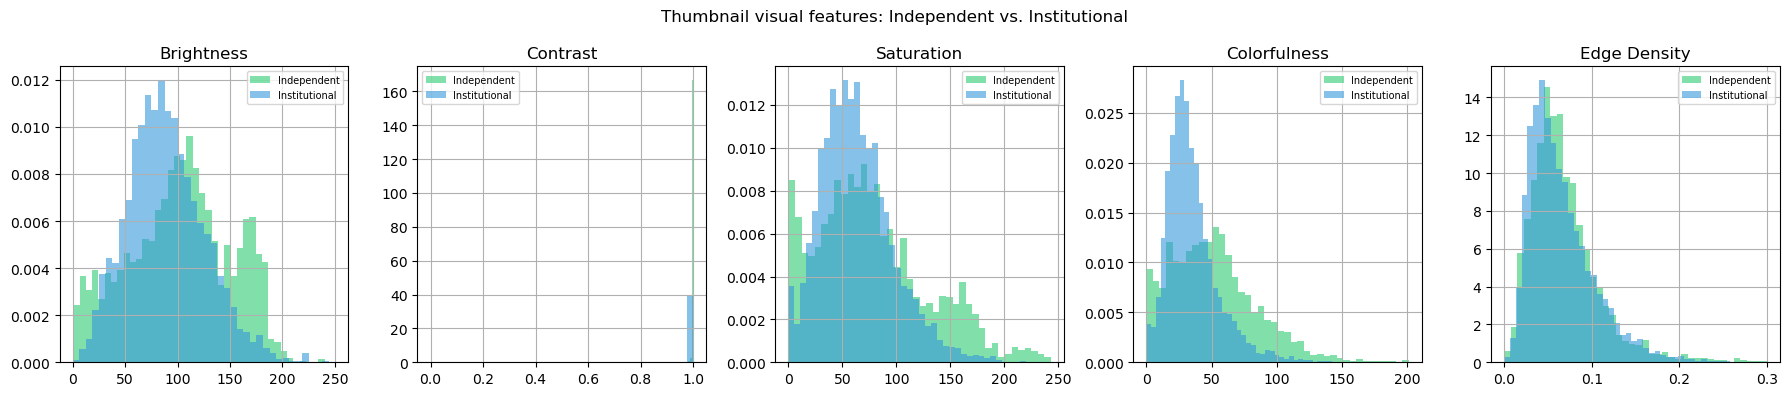

In [25]:
# Merge with manifest for group label
cv_merged = cv_df.merge(manifest[['video_id', 'group_label', 'view_count', 'like_count', 'comment_count']], on='video_id')

PALETTE = {'independent': '#2ecc71', 'institutional': '#3498db'}
visual_feats = ['brightness', 'contrast', 'saturation', 'colorfulness', 'edge_density']

fig, axes = plt.subplots(1, len(visual_feats), figsize=(18, 4))
for ax, feat in zip(axes, visual_feats):
    for grp, color in PALETTE.items():
        vals = cv_merged[cv_merged['group_label'].str.lower() == grp][feat].dropna()
        vals.hist(ax=ax, bins=40, alpha=0.6, color=color, label=grp.title(), density=True)
    ax.set_title(feat.replace('_', ' ').title())
    ax.legend(fontsize=7)
plt.suptitle('Thumbnail visual features: Independent vs. Institutional')
plt.tight_layout()
plt.savefig(FIGURES / 'opencv_distributions.png', dpi=150)
plt.show()

---
## TIER 2 — CLIP zero-shot semantic classification

CLIP lets us ask visual questions in plain English without any training data.
We define pairs of opposing text prompts and score each thumbnail against them.

In [26]:
import torch
import open_clip
from PIL import Image

# Load CLIP — ViT-B/32 is fast; upgrade to ViT-L/14 for better accuracy
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
tokenizer = open_clip.get_tokenizer('ViT-B-32')
model.eval()
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(DEVICE)
print(f"CLIP on {DEVICE}")

/Users/alexlag/miniconda3/envs/ada2025/lib/python3.14/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP on cpu


In [28]:
# Each question is a (positive_label, list_of_prompts) pair.
# The score = softmax probability of the first prompt in the list.
CLIP_QUESTIONS = {
    'has_face': [
        'a YouTube thumbnail showing a human face or person',
        'a YouTube thumbnail with no people, only text, objects or graphics'
    ],
    'is_animated': [
        'an animated or illustrated YouTube thumbnail, cartoon style',
        'a photographic, real-world YouTube thumbnail'
    ],
    'has_text_overlay': [
        'a YouTube thumbnail with large bold text or title overlay',
        'a YouTube thumbnail with no text or very minimal text'
    ],
    'is_diagram': [
        'a scientific diagram, graph, equation, or whiteboard content',
        'a lifestyle, interview, or entertainment style thumbnail'
    ],
    'is_colorful': [
        'a very bright and colorful YouTube thumbnail with vivid colors',
        'a dark, muted, or monochrome YouTube thumbnail'
    ],
    'is_professional': [
        'a polished, professionally designed YouTube thumbnail',
        'a simple, low-effort or raw screenshot thumbnail'
    ],
    'is_clickbait': [
        'a clickbait, sensational, shocking or exaggerated YouTube thumbnail',
        'a calm, factual, educational YouTube thumbnail'
    ],
}

# Pre-encode all text prompts
encoded_questions = {}
for key, prompts in CLIP_QUESTIONS.items():
    tokens = tokenizer(prompts).to(DEVICE)
    with torch.no_grad():
        text_feats = model.encode_text(tokens)
        text_feats /= text_feats.norm(dim=-1, keepdim=True)
    encoded_questions[key] = text_feats

print("Text prompts encoded")

Text prompts encoded


In [29]:
BATCH_SIZE = 64

def load_image(path):
    try:
        return preprocess(Image.open(path).convert('RGB'))
    except Exception:
        return None

all_clip_rows = []

paths = manifest['thumb_path'].tolist()
video_ids = manifest['video_id'].tolist()

for start in tqdm(range(0, len(paths), BATCH_SIZE), desc='CLIP batches'):
    batch_paths = paths[start:start+BATCH_SIZE]
    batch_ids   = video_ids[start:start+BATCH_SIZE]

    imgs, valid_ids = [], []
    for pid, vid in zip(batch_paths, batch_ids):
        img = load_image(pid)
        if img is not None:
            imgs.append(img)
            valid_ids.append(vid)

    if not imgs:
        continue

    batch_tensor = torch.stack(imgs).to(DEVICE)
    with torch.no_grad():
        img_feats = model.encode_image(batch_tensor)
        img_feats /= img_feats.norm(dim=-1, keepdim=True)

    for i, vid in enumerate(valid_ids):
        row = {'video_id': vid}
        for key, text_feats in encoded_questions.items():
            # cosine similarities → softmax probability for first prompt (positive class)
            sim = (img_feats[i] @ text_feats.T) * 100
            prob = torch.softmax(sim, dim=0)[0].item()
            row[f'clip_{key}'] = prob
        all_clip_rows.append(row)

clip_df = pd.DataFrame(all_clip_rows)
clip_df.to_csv(TABLES / 'clip_features.csv', index=False)
print(f"Saved CLIP features for {len(clip_df)} thumbnails")
clip_df.head()

CLIP batches:   0%|          | 0/150 [00:00<?, ?it/s]

Saved CLIP features for 9568 thumbnails


,video_id,clip_has_face,clip_is_animated,clip_has_text_overlay,clip_is_diagram,clip_is_colorful,clip_is_professional,clip_is_clickbait
0,--4MpKow8ro,0.032318,0.047816,0.744494,0.002581,0.627338,0.815921,0.301807
1,--ZfVZbmKbY,0.313570,0.061886,0.801003,0.036256,0.128670,0.726237,0.134266
2,--aYHgPKGIs,0.320189,0.003293,0.666272,0.329975,0.860883,0.977463,0.193920
3,--qKOhdgJAs,0.051109,0.236653,0.776672,0.142242,0.982304,0.944813,0.082736
4,--sBEWfPfKA,0.335543,0.020333,0.764227,0.009264,0.927001,0.649509,0.253811


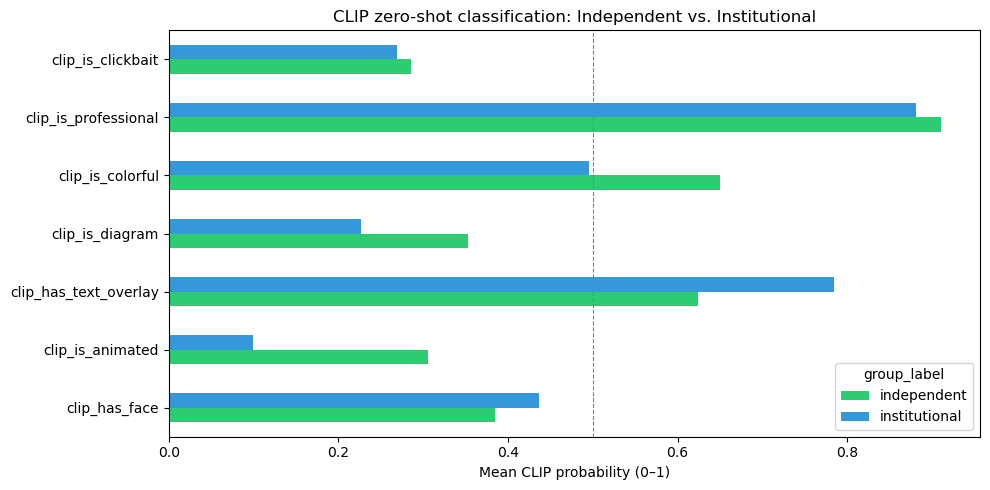

group_label,independent,institutional
clip_has_face,0.384,0.436
clip_is_animated,0.305,0.099
clip_has_text_overlay,0.623,0.785
clip_is_diagram,0.352,0.227
clip_is_colorful,0.650,0.495
clip_is_professional,0.911,0.881
clip_is_clickbait,0.286,0.269


In [30]:
clip_merged = clip_df.merge(manifest[['video_id', 'group_label']], on='video_id')

clip_cols = [c for c in clip_df.columns if c.startswith('clip_')]
grp_means = clip_merged.groupby('group_label')[clip_cols].mean().T

fig, ax = plt.subplots(figsize=(10, 5))
grp_means.plot(kind='barh', ax=ax, color=['#2ecc71', '#3498db'])
ax.set_xlabel('Mean CLIP probability (0–1)')
ax.set_title('CLIP zero-shot classification: Independent vs. Institutional')
ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig(FIGURES / 'clip_classification_comparison.png', dpi=150)
plt.show()
grp_means.round(3)

---
## TIER 3 — BLIP (HuggingFace, free, runs locally)

Two lightweight models replace any paid API:

| Model | Size | Role |
|-------|------|------|
| `Salesforce/blip-vqa-base` | ~370 MB | Visual QA → boolean features + channel type guess |
| `Salesforce/blip-image-captioning-large` | ~900 MB | Captioning → main_subject description |

Subjective 1–5 scores (appeal, professionalism, complexity) are derived from
the CLIP probabilities already computed in Tier 2 — no extra model needed.

Install (one-time): `pip install transformers`

Run on a **stratified sample of ~320 thumbnails** — BLIP takes ~1–2 s/image on CPU, so ~10 min total.

In [31]:
import torch
from transformers import BlipProcessor, BlipForQuestionAnswering, BlipForConditionalGeneration
from PIL import Image

SAMPLE_PER_CHANNEL = 40  # 8 channels × 40 = 320 total

sample = (
    manifest
    .groupby('channel_title', group_keys=False)
    .apply(lambda g: g.sample(min(len(g), SAMPLE_PER_CHANNEL), random_state=42))
    .reset_index(drop=True)
)
print(f"Sample: {len(sample)} thumbnails across {sample['channel_title'].nunique()} channels")

# MPS = Apple Silicon GPU, CUDA = Nvidia, else CPU
DEVICE = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {DEVICE}")

# VQA model — answers yes/no questions about an image
vqa_processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
vqa_model = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-base").to(DEVICE)
vqa_model.eval()

# Captioning model — generates a text description of the image
cap_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-large")
cap_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-large").to(DEVICE)
cap_model.eval()

print("Models loaded")

/var/folders/rk/jv2f_96j46v5vnvmjd2zk_1r0000gn/T/ipykernel_64261/1241480427.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), SAMPLE_PER_CHANNEL), random_state=42))


Sample: 320 thumbnails across 8 channels
Running on: mps
Models loaded


In [32]:
VQA_QUESTIONS = {
    'has_face':          'Is there a human face or person in this image?',
    'has_text_overlay':  'Is there text written on this image?',
    'is_animated':       'Is this an animated or cartoon image?',
    'is_diagram':        'Does this image show a scientific diagram, graph or equation?',
    'curiosity_trigger': 'Does this image make you want to watch the video?',
    'is_institutional':  'Does this look like an official university or institution video?',
}

YES_TOKENS = {'yes', 'yeah', 'true', 'correct', 'definitely', 'absolutely'}

def ask_vqa(image: Image.Image, question: str) -> bool:
    inputs = vqa_processor(image, question, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        out = vqa_model.generate(**inputs, max_new_tokens=5)
    answer = vqa_processor.decode(out[0], skip_special_tokens=True).strip().lower()
    return answer in YES_TOKENS

def get_caption(image: Image.Image) -> str:
    inputs = cap_processor(image, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        out = cap_model.generate(**inputs, max_new_tokens=40)
    return cap_processor.decode(out[0], skip_special_tokens=True).strip()

def analyse_thumbnail_blip(path: str) -> dict | None:
    try:
        image = Image.open(path).convert('RGB')
    except Exception:
        return None

    result = {}
    for key, question in VQA_QUESTIONS.items():
        result[key] = ask_vqa(image, question)

    result['channel_type_guess'] = 'institutional' if result.pop('is_institutional') else 'independent'
    result['main_subject'] = get_caption(image)
    return result

# Sanity check on one image
print(analyse_thumbnail_blip(sample['thumb_path'].iloc[0]))

{'has_face': False, 'has_text_overlay': True, 'is_animated': False, 'is_diagram': False, 'curiosity_trigger': False, 'channel_type_guess': 'independent', 'main_subject': 'a close up of a computer screen with a keyboard and a mouse'}


In [33]:
vision_results = []

for _, row in tqdm(sample.iterrows(), total=len(sample), desc='BLIP analysis'):
    result = analyse_thumbnail_blip(row['thumb_path'])
    if result:
        result['video_id']      = row['video_id']
        result['channel_title'] = row['channel_title']
        result['group_label']   = row['group_label']
        vision_results.append(result)

vision_df = pd.DataFrame(vision_results)

# --- Derive 1–5 scores from already-computed Tier 2 outputs ---
clip_feats = pd.read_csv(TABLES / 'clip_features.csv')
cv_feats   = pd.read_csv(TABLES / 'opencv_features.csv')

vision_df = vision_df.merge(
    clip_feats[['video_id', 'clip_is_professional', 'clip_is_colorful', 'clip_has_face']],
    on='video_id', how='left'
).merge(
    cv_feats[['video_id', 'edge_density']],
    on='video_id', how='left'
)

# CLIP probability (0–1) → 1–5 score
vision_df['professionalism'] = (vision_df['clip_is_professional'] * 4 + 1).round(1)
vision_df['appeal_score'] = (
    vision_df['clip_is_professional'] * 0.5 +
    vision_df['clip_is_colorful']     * 0.3 +
    vision_df['clip_has_face']        * 0.2
).mul(4).add(1).round(1)
# Edge density (busyness) → complexity 1–5
ed = vision_df['edge_density']
vision_df['complexity'] = ((ed - ed.min()) / (ed.max() - ed.min() + 1e-9) * 4 + 1).round(1)

vision_df = vision_df.drop(columns=['clip_is_professional', 'clip_is_colorful', 'clip_has_face', 'edge_density'])

vision_df.to_csv(TABLES / 'vision_features.csv', index=False)
print(f"Saved {len(vision_df)} BLIP annotations")
vision_df.head()

BLIP analysis:   0%|          | 0/320 [00:00<?, ?it/s]

Saved 320 BLIP annotations


,has_face,has_text_overlay,is_animated,is_diagram,curiosity_trigger,channel_type_guess,main_subject,video_id,channel_title,group_label,professionalism,appeal_score,complexity
0,False,True,False,False,False,independent,a close up of a computer screen with a keyboar...,w-CXIqIjfRI,3Blue1Brown,independent,2.4,1.8,1.2
1,False,True,False,True,False,independent,a black background with a picture of a black a...,Iq1a_KJTWJ8,3Blue1Brown,independent,2.4,2.0,1.1
2,False,False,False,False,False,independent,there is a picture of a white chair in a room,1lZpowy21Gc,3Blue1Brown,independent,4.7,2.9,1.1
3,False,True,False,False,False,independent,a close up of two different types of 3d cubes,piJkuavhV50,3Blue1Brown,independent,5.0,3.7,1.6
4,False,True,False,False,False,independent,the logo for the new website,3s7h2MHQtxc,3Blue1Brown,independent,4.7,3.6,1.3


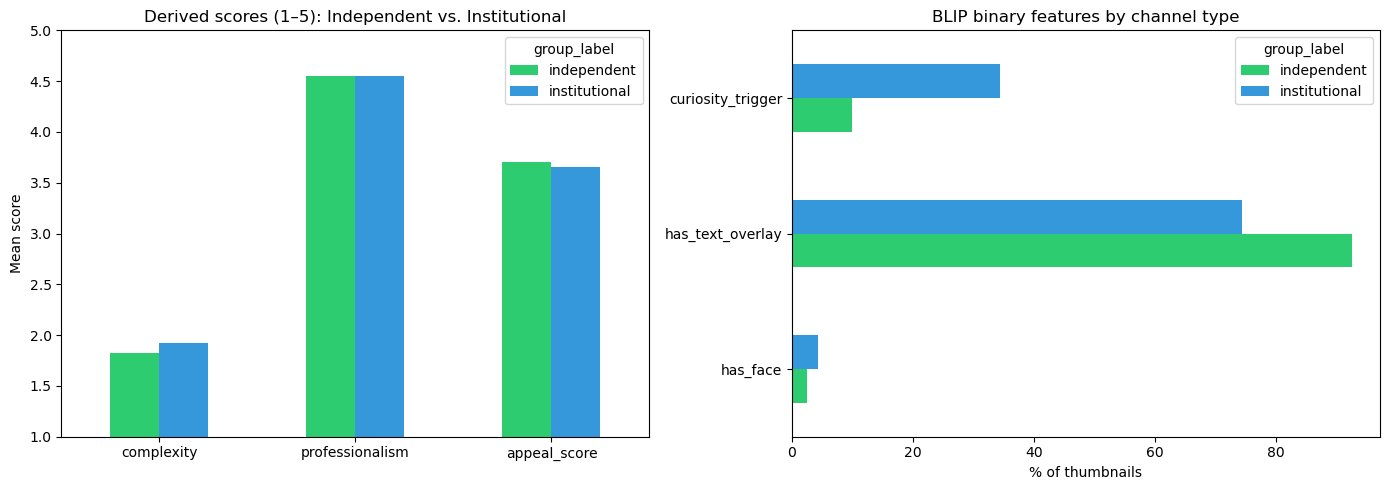

In [34]:
import seaborn as sns

numeric_vision = ['complexity', 'professionalism', 'appeal_score']
bool_vision    = ['has_face', 'has_text_overlay', 'curiosity_trigger']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

score_means = vision_df.groupby('group_label')[numeric_vision].mean().T
score_means.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#3498db'], rot=0)
axes[0].set_ylim(1, 5)
axes[0].set_title('Derived scores (1–5): Independent vs. Institutional')
axes[0].set_ylabel('Mean score')

bool_means = vision_df.groupby('group_label')[bool_vision].mean().mul(100).T
bool_means.plot(kind='barh', ax=axes[1], color=['#2ecc71', '#3498db'])
axes[1].set_xlabel('% of thumbnails')
axes[1].set_title('BLIP binary features by channel type')

plt.tight_layout()
plt.savefig(FIGURES / 'blip_vision_summary.png', dpi=150)
plt.show()

Logistic Regression on CLIP + OpenCV features (5-fold CV, n=320)

               precision    recall  f1-score   support

  independent       0.82      0.76      0.79       160
institutional       0.77      0.83      0.80       160

     accuracy                           0.79       320
    macro avg       0.80      0.79      0.79       320
 weighted avg       0.80      0.79      0.79       320



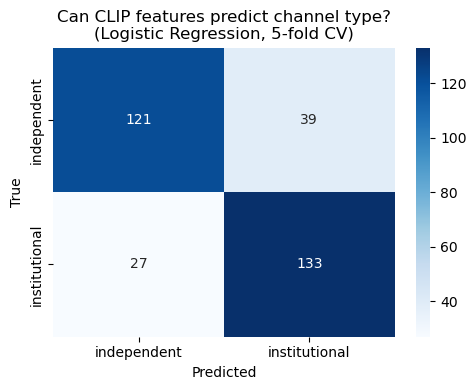


Top discriminating features (positive → institutional, negative → independent):
clip_is_animated        -1.199
clip_is_diagram         -0.908
clip_has_text_overlay    0.736
colorfulness            -0.324
clip_is_colorful        -0.306
contrast                -0.289
saturation              -0.259
brightness               0.191


In [35]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# Merge CLIP + OpenCV features into the 320-sample subset
clip_feats_all = pd.read_csv(TABLES / 'clip_features.csv')
cv_feats_all   = pd.read_csv(TABLES / 'opencv_features.csv')
vis_clf = (vision_df
           .merge(clip_feats_all, on='video_id')
           .merge(cv_feats_all, on='video_id'))

clip_cols_clf = [c for c in clip_feats_all.columns if c.startswith('clip_')]
cv_cols_clf   = ['brightness', 'contrast', 'saturation', 'colorfulness', 'edge_density']
feature_cols_clf = clip_cols_clf + cv_cols_clf

X_clf = vis_clf[feature_cols_clf].values
y_clf = (vis_clf['group_label'].str.lower() == 'institutional').astype(int)

# 5-fold stratified cross-validation with logistic regression
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
preds = cross_val_predict(clf, X_clf, y_clf, cv=cv)
pred_labels = np.where(preds == 1, 'institutional', 'independent')
true_labels = vis_clf['group_label'].str.lower().values

print("Logistic Regression on CLIP + OpenCV features (5-fold CV, n=320)\n")
print(classification_report(true_labels, pred_labels))

cm = confusion_matrix(true_labels, pred_labels, labels=['independent', 'institutional'])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['independent', 'institutional'],
            yticklabels=['independent', 'institutional'], cmap='Blues', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Can CLIP features predict channel type?\n(Logistic Regression, 5-fold CV)')
plt.tight_layout()
plt.savefig(FIGURES / 'clip_lr_type_guess_cm.png', dpi=150)
plt.show()

# Show which features are most discriminative
clf.fit(X_clf, y_clf)
coef_df = (pd.Series(clf.named_steps['lr'].coef_[0], index=feature_cols_clf)
           .sort_values(key=abs, ascending=False)
           .head(8))
print("\nTop discriminating features (positive → institutional, negative → independent):")
print(coef_df.round(3).to_string())

In [36]:
bool_by_channel = (
    vision_df.groupby(['channel_title', 'group_label'])[bool_vision]
    .mean()
    .mul(100)
    .round(1)
)
bool_by_channel.to_csv(TABLES / 'blip_bool_by_channel.csv')

# Qualitative inspection — sample captions per channel type
print("=== Sample captions ===")
for grp in ['independent', 'institutional']:
    print(f"\n--- {grp.title()} ---")
    subset = vision_df[vision_df['group_label'].str.lower() == grp]
    print('\n'.join(subset['main_subject'].sample(5, random_state=1).tolist()))

bool_by_channel

=== Sample captions ===

--- Independent ---
a close up of a person in a blue shirt with a bookcase in the background
a penguin is standing in front of a door with a sign that says how to kurzest
a close up of a person standing in front of a computer screen
someone is drawing a diagram on a white board with markers
a dress made out of multicolored material on a stand

--- Institutional ---
arafed man standing in front of a mountain with a river in the background
there is a man standing in a room with a camera and a robot
a computer screen showing a computer screen with a curved object
arafed image of a man standing at a podium with a microphone
arafed woman writing on a wall in a tunnel


,,has_face,has_text_overlay,curiosity_trigger
channel_title,group_label,,,
3Blue1Brown,independent,0.0,90.0,10.0
EPFL,institutional,2.5,80.0,55.0
ETH Zürich,institutional,0.0,77.5,37.5
Kurzgesagt – In a Nutshell,independent,5.0,97.5,22.5
Lectures by Walter Lewin. They will make you ♥ Physics.,independent,5.0,85.0,5.0
Massachusetts Institute of Technology (MIT),institutional,12.5,75.0,25.0
Stanford,institutional,2.5,65.0,20.0
minutephysics,independent,0.0,97.5,2.5
